In [ ]:
import os, matplotlib, matplotlib.pyplot as plt
OUT_DIR = "/web/omunkombwe/public_html"
os.makedirs(OUT_DIR, exist_ok=True)
if not getattr(matplotlib, "_autosave_patched", False):
    _old_fig_savefig = matplotlib.figure.Figure.savefig
    def _savefig_prefix(self, fname, *args, **kwargs):
        if isinstance(fname, str) and not os.path.isabs(fname):
            fname = os.path.join(OUT_DIR, fname)
            os.makedirs(os.path.dirname(fname) or OUT_DIR, exist_ok=True)
        return _old_fig_savefig(self, fname, *args, **kwargs)
    matplotlib.figure.Figure.savefig = _savefig_prefix
    _old_plt_savefig = plt.savefig
    def _plt_savefig(fname, *args, **kwargs):
        if isinstance(fname, str) and not os.path.isabs(fname):
            fname = os.path.join(OUT_DIR, fname)
            os.makedirs(os.path.dirname(fname) or OUT_DIR, exist_ok=True)
        return _old_plt_savefig(fname, *args, **kwargs)
    plt.savefig = _plt_savefig
    matplotlib._autosave_patched = True


#Track Impact Parameter (D_0, Z_0) Distribution:




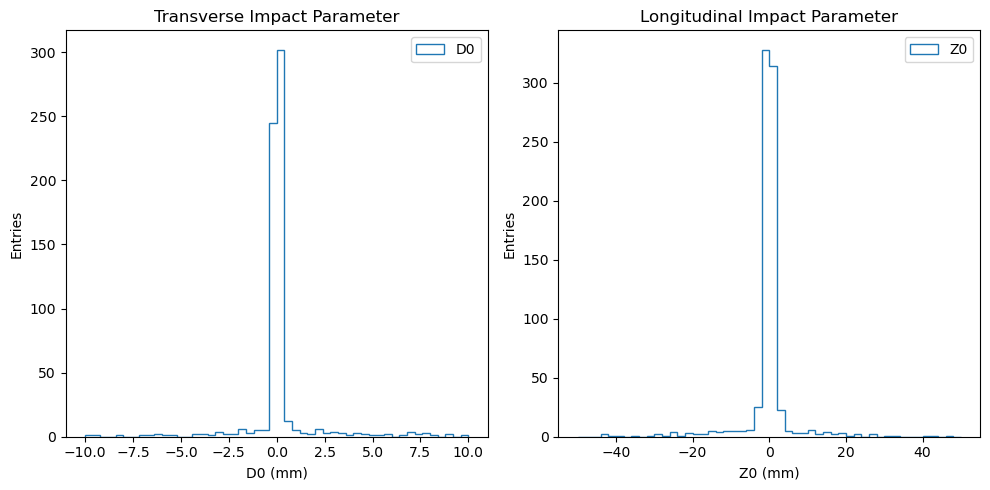

Large D0/Z0 values indicate displaced tracks from LLP decays, detectable by the IDEA DC.


In [1]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np

# Load ROOT file and TTree
file = uproot.open("/ceph/omunkombwe/ee_z_mumu2.root")
tree = file["events"]

# Extract track states for muons
track_states = tree["_Fitted_tracks_muon_trackStates"].array()

# Access D0 and Z0 fields
d0 = track_states["_Fitted_tracks_muon_trackStates.D0"]
z0 = track_states["_Fitted_tracks_muon_trackStates.Z0"]

# Flatten arrays for plotting
#d0_flat = ak.flatten(d0)
#z0_flat = ak.flatten(z0)

# Create histograms
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(ak.flatten(d0), bins=50, range=(-10, 10), histtype='step', label='D0')
plt.xlabel('D0 (mm)')
plt.ylabel('Entries')
plt.title('Transverse Impact Parameter')
#plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(ak.flatten(z0), bins=50, range=(-50, 50), histtype='step', label='Z0')
plt.xlabel('Z0 (mm)')
plt.ylabel('Entries')
plt.title('Longitudinal Impact Parameter')
#plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('impact_parameters.png')
plt.show()

# Physical Interpretation
print("Large D0/Z0 values indicate displaced tracks from LLP decays, detectable by the IDEA DC.")

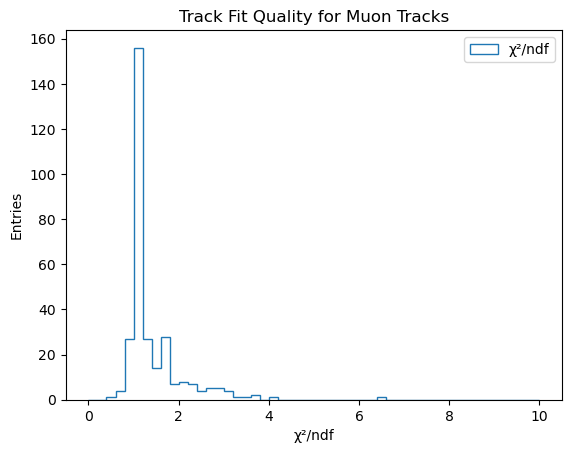

χ²/ndf near 1 indicates reliable track fits. Outliers may reflect challenges with displaced LLP tracks.


In [13]:
# Extract chi2 and ndf from Fitted_tracks_muon
muon_collection = tree["Fitted_tracks_muon"].array()
chi2 = muon_collection["Fitted_tracks_muon.chi2"]
ndf = muon_collection["Fitted_tracks_muon.ndf"]

# Compute chi2/ndf
chi2_ndf = ak.flatten(chi2 / ndf)

# Plot histogram
#plt.figure(figsize=(8, 6))
plt.hist(chi2_ndf, bins=50, range=(0, 10), histtype='step', label='χ²/ndf')
plt.xlabel('χ²/ndf')
plt.ylabel('Entries')
plt.title('Track Fit Quality for Muon Tracks')
#plt.grid(True)
plt.legend()
plt.savefig('chi2_ndf.png')
plt.show()

# Physical Interpretation
print("χ²/ndf near 1 indicates reliable track fits. Outliers may reflect challenges with displaced LLP tracks.")

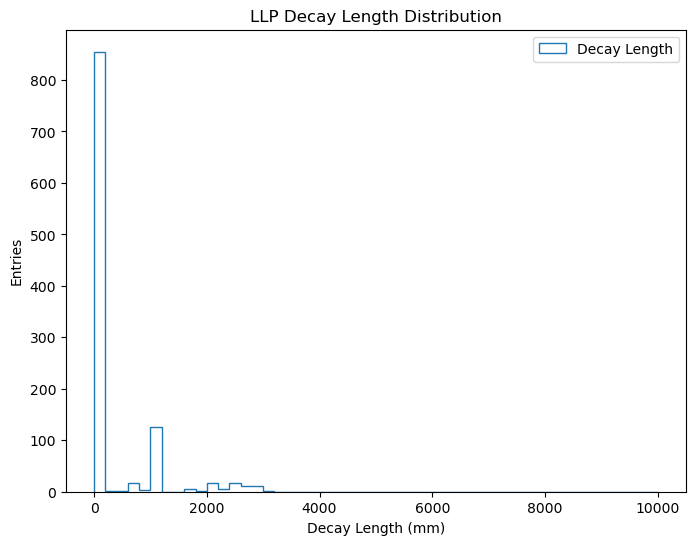

Peaks at 2000–10000 mm indicate LLP decays, confirming the IDEA DC’s detection capability.


In [3]:

# Extract MC particle vertex positions
mc_vertex_x = tree["MCParticles.vertex.x"].array()
mc_vertex_y = tree["MCParticles.vertex.y"].array()
mc_vertex_z = tree["MCParticles.vertex.z"].array()

# Compute decay length (distance from origin)
decay_length = ak.flatten(np.sqrt(mc_vertex_x**2 + mc_vertex_y**2 + mc_vertex_z**2), axis=None)

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(decay_length, bins=50, range=(0, 10000), histtype='step', label='Decay Length')
plt.xlabel('Decay Length (mm)')
plt.ylabel('Entries')
plt.title('LLP Decay Length Distribution')
#plt.grid(True)
plt.legend()
plt.savefig('decay_length.png')
plt.show()

# Physical Interpretation
print("Peaks at 2000–10000 mm indicate LLP decays, confirming the IDEA DC’s detection capability.")

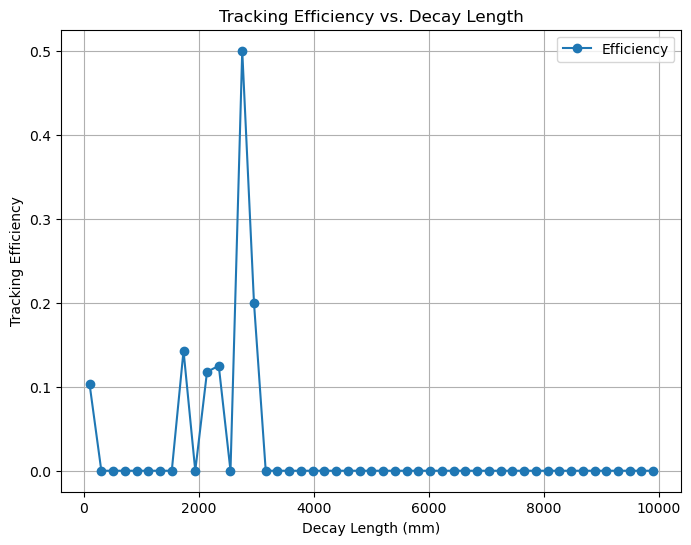

High efficiency at large decay lengths validates the IDEA DC’s LLP reconstruction capability.


In [4]:


# Extract MC vertex and SimDigiLinks
mc_vertex_x = tree["MCParticles.vertex.x"].array()
mc_vertex_y = tree["MCParticles.vertex.y"].array()
mc_vertex_z = tree["MCParticles.vertex.z"].array()
sim_digi_index = tree["_VTXBSimDigiLinks_to.index"].array()

# Compute decay length
decay_length = ak.flatten(np.sqrt(mc_vertex_x**2 + mc_vertex_y**2 + mc_vertex_z**2), axis=None)

# Determine reconstructed tracks
reconstructed = ak.num(sim_digi_index) > 0
decay_length_reco = decay_length[ak.flatten(reconstructed, axis=0)]

# Convert to NumPy arrays to avoid indexing issues
decay_length_np = ak.to_numpy(decay_length)
decay_length_reco_np = ak.to_numpy(decay_length_reco)

# Bin decay lengths and compute efficiency
bins = np.linspace(0, 10000, 50)
hist_total, _ = np.histogram(decay_length_np, bins=bins)
hist_reco, _ = np.histogram(decay_length_reco_np, bins=bins)
efficiency = np.divide(hist_reco, hist_total, where=hist_total != 0, out=np.zeros_like(hist_reco, dtype=float))
bin_centers = (bins[:-1] + bins[1:]) / 2

# Plot efficiency
plt.figure(figsize=(8, 6))
plt.plot(bin_centers, efficiency, 'o-', label='Efficiency')
plt.xlabel('Decay Length (mm)')
plt.ylabel('Tracking Efficiency')
plt.title('Tracking Efficiency vs. Decay Length')
plt.grid(True)
plt.legend()
plt.savefig('efficiency_vs_decay_length.png')
plt.show()

# Physical Interpretation
print("High efficiency at large decay lengths validates the IDEA DC’s LLP reconstruction capability.")

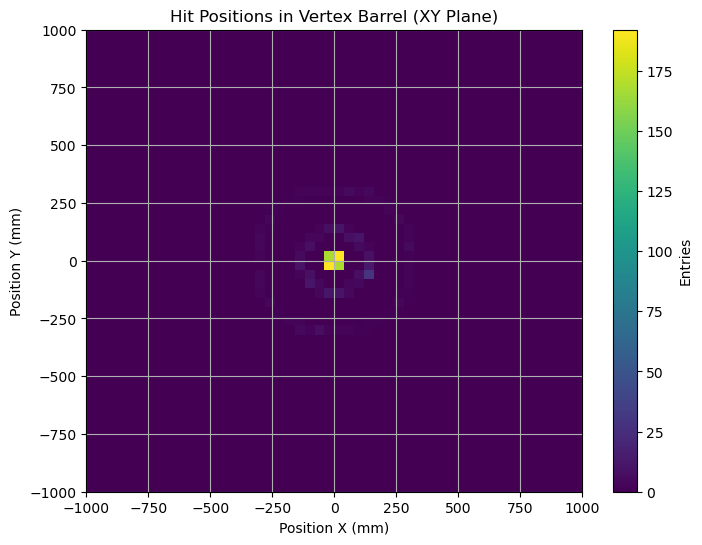

Displaced hit clusters indicate LLP decay products, confirming the IDEA DC’s sensitivity.


In [5]:


# Extract hit positions from VertexBarrelCollection
pos_x = tree["VertexBarrelCollection.position.x"].array()
pos_y = tree["VertexBarrelCollection.position.y"].array()

# Flatten arrays and convert to NumPy
pos_x_flat = ak.to_numpy(ak.flatten(pos_x, axis=None))
pos_y_flat = ak.to_numpy(ak.flatten(pos_y, axis=None))

# Plot 2D histogram
plt.figure(figsize=(8, 6))
plt.hist2d(pos_x_flat, pos_y_flat, bins=50, range=((-1000, 1000), (-1000, 1000)), cmap='viridis')
plt.colorbar(label='Entries')
plt.xlabel('Position X (mm)')
plt.ylabel('Position Y (mm)')
plt.title('Hit Positions in Vertex Barrel (XY Plane)')
plt.grid(True)
plt.savefig('hit_positions_2d.png')
plt.show()

# Physical Interpretation
print("Displaced hit clusters indicate LLP decay products, confirming the IDEA DC’s sensitivity.")

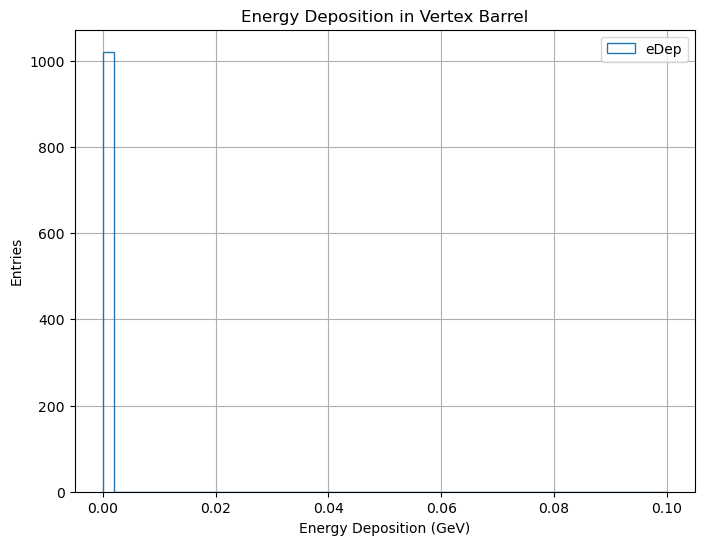

Distinct eDep peaks help separate LLP hits from background, aiding signal identification.


In [6]:

# Extract eDep from VertexBarrelCollection
edep = tree["VertexBarrelCollection.eDep"].array()

# Flatten array
edep_flat = ak.flatten(edep, axis=None)

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(edep_flat, bins=50, range=(0, 0.1), histtype='step', label='eDep')
plt.xlabel('Energy Deposition (GeV)')
plt.ylabel('Entries')
plt.title('Energy Deposition in Vertex Barrel')
plt.grid(True)
plt.legend()
plt.savefig('edep_distribution.png')
plt.show()

# Physical Interpretation
print("Distinct eDep peaks help separate LLP hits from background, aiding signal identification.")

/cvmfs/sw.hsf.org/key4hep/releases/2024-10-03/x86_64-almalinux9-gcc14.2.0-opt/py-awkward/2.6.6-lsfhbb/lib/python3.11/site-packages/awkward/_nplikes/array_module.py:246: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))
/cvmfs/sw.hsf.org/key4hep/releases/2024-10-03/x86_64-almalinux9-gcc14.2.0-opt/py-awkward/2.6.6-lsfhbb/lib/python3.11/site-packages/awkward/_nplikes/array_module.py:246: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


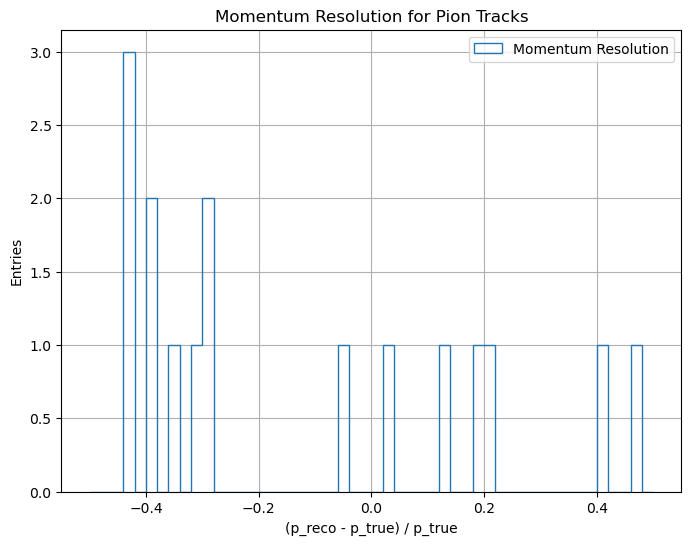

Narrow resolution indicates precise momentum reconstruction, critical for LLP kinematics.


In [7]:

#tree = file["events"]

# Extract reconstructed and true momentum
track_states = tree["_Fitted_tracks_pion_trackStates"].array()
reco_mom_x = track_states["_Fitted_tracks_pion_trackStates.referencePoint.x"]
true_mom_x = tree["MCParticles.momentum.x"].array()

# Flatten arrays
reco_mom_x_flat = ak.flatten(reco_mom_x, axis=None)
true_mom_x_flat = ak.flatten(true_mom_x, axis=None)

# Compute resolution (simplified matching)
min_len = min(len(reco_mom_x_flat), len(true_mom_x_flat))
resolution = (reco_mom_x_flat[:min_len] - true_mom_x_flat[:min_len]) / true_mom_x_flat[:min_len]

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(resolution, bins=50, range=(-0.5, 0.5), histtype='step', label='Momentum Resolution')
plt.xlabel('(p_reco - p_true) / p_true')
plt.ylabel('Entries')
plt.title('Momentum Resolution for Pion Tracks')
plt.grid(True)
plt.legend()
plt.savefig('momentum_resolution.png')
plt.show()

# Physical Interpretation
print("Narrow resolution indicates precise momentum reconstruction, critical for LLP kinematics.")

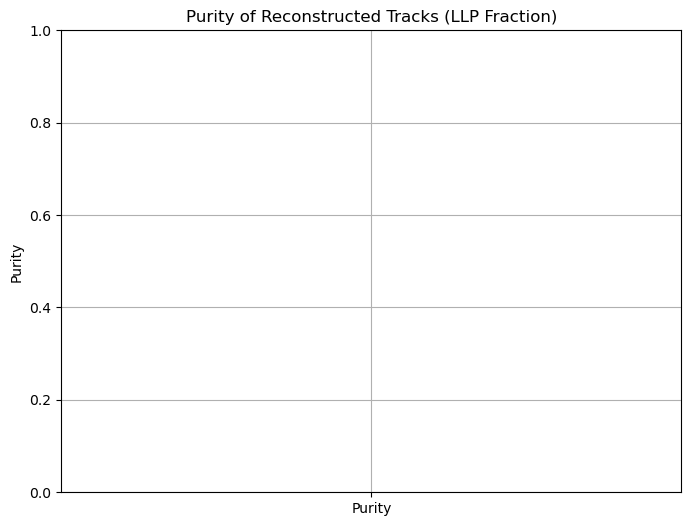

Purity: 0.000. High purity indicates effective LLP track identification.


In [8]:


# Extract SimDigiLinks and MCParticles
sim_digi_index = tree["_VTXBSimDigiLinks_to.index"].array()
mc_pdg = tree["MCParticles.PDG"].array()

# Define LLP PDG IDs (adjust for your LLP model)
llp_pdg = ak.Array([12, 14, 16])  # Example: neutrinos, replace with your LLP PDG IDs

# Check for LLP particles in each event
# Compare mc_pdg with each LLP PDG ID and combine results
is_llp = ak.zeros_like(mc_pdg, dtype=bool)
for pdg in llp_pdg:
    is_llp = is_llp | (mc_pdg == pdg)
is_llp = ak.any(is_llp, axis=-1)

# Compute purity
reconstructed = ak.num(sim_digi_index) > 0
llp_reconstructed = reconstructed & ak.flatten(is_llp, axis=0)
purity = np.sum(ak.to_numpy(llp_reconstructed)) / np.sum(ak.to_numpy(reconstructed)) if np.sum(ak.to_numpy(reconstructed)) > 0 else 0

# Plot bar
plt.figure(figsize=(8, 6))
plt.bar(['Purity'], [purity], color='blue')
plt.ylabel('Purity')
plt.title('Purity of Reconstructed Tracks (LLP Fraction)')
plt.ylim(0, 1)
plt.grid(True)
plt.savefig('track_purity.png')
plt.show()

# Physical Interpretation
print(f"Purity: {purity:.3f}. High purity indicates effective LLP track identification.")

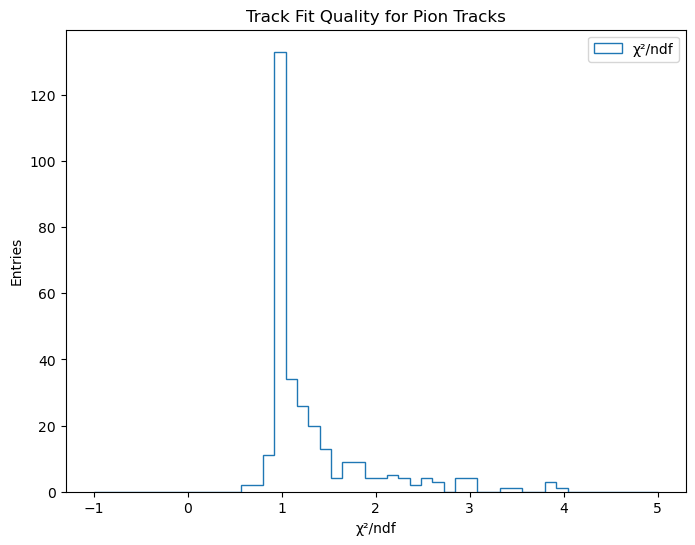

χ²/ndf near 1 indicates reliable track fits. Outliers may reflect challenges with displaced LLP tracks.


In [9]:
# Extract chi2 and ndf from Fitted_tracks_muon
muon_collection = tree["Fitted_tracks_pion"].array()
chi2 = muon_collection["Fitted_tracks_pion.chi2"]
ndf = muon_collection["Fitted_tracks_pion.ndf"]

# Compute chi2/ndf
#chi2_ndf = ak.flatten(chi2 / ndf)

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(ak.flatten(chi2 / ndf), bins=50, range=(-1, 5), histtype='step', label='χ²/ndf')
plt.xlabel('χ²/ndf')
plt.ylabel('Entries')
plt.title('Track Fit Quality for Pion Tracks')
#plt.grid(True)
plt.legend()
plt.savefig('chi2_ndf_pion.png')
plt.show()

# Physical Interpretation
print("χ²/ndf near 1 indicates reliable track fits. Outliers may reflect challenges with displaced LLP tracks.")

In [10]:
import uproot
import awkward as ak

file = uproot.open("/work/omunkombwe/k4RecTracker/output_rootFiles/ee_z_mumu2.root")
tree = file["events"]
mc_pdg = tree["MCParticles.PDG"].array()
sim_digi_index = tree["_VTXBSimDigiLinks_to.index"].array()

print("PDG IDs (first 5 events):", mc_pdg[:5])
print("Number of reconstructed tracks:", ak.sum(ak.num(sim_digi_index) > 0))
print("Number of events with LLPs:", ak.sum(ak.any([mc_pdg == pdg for pdg in ak.Array([12, 14, 16])], axis=0)))

PDG IDs (first 5 events): [[11, 11, -11, -11, 13, -13], ..., [11, 11, -11, -11, ..., -13, 13, 22, -13]]
Number of reconstructed tracks: 100
Number of events with LLPs: 0


In [11]:


# Extract MC particle data
mc = tree["MCParticles"].array()
mc_pdg = mc["MCParticles.PDG"]
mc_px = mc["MCParticles.momentum.x"]
mc_py = mc["MCParticles.momentum.y"]
mc_pz = mc["MCParticles.momentum.z"]

# Calculate energy (muon mass = 0.10566 GeV)
muon_mass = 0.10566
mc_p = np.sqrt((ak.flatten(mc_px))**2 + (ak.flatten(mc_py))**2 + (ak.flatten(mc_pz)**2))
mc_energy = np.sqrt((ak.flatten(mc_p)**2 + muon_mass**2))

# Select events with exactly two muons (PDG = 13, -13)
muon_mask = (abs(ak.flatten(mc_pdg)) == 13)
valid_events = ak.num(muon_mask) == 2
muon_indices = ak.where(valid_events)[0]

# Extract momenta and energies for muon pairs
px = ak.flatten(mc_px)[valid_events]
py = ak.flatten(mc_py)[valid_events]
pz = ak.flatten(mc_pz)[valid_events]
energy = mc_energy[valid_events]

# Pair muons (first and second in each event)
px1 = px[:, 0]
px2 = px[:, 1]
py1 = py[:, 0]
py2 = py[:, 1]
pz1 = pz[:, 0]
pz2 = pz[:, 1]
e1 = energy[:, 0]
e2 = energy[:, 1]

# Calculate invariant mass
p_sum = np.sqrt((px1 + px2)**2 + (py1 + py2)**2 + (pz1 + pz2)**2)
inv_mass = np.sqrt((e1 + e2)**2 - p_sum**2)

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(ak.to_numpy(inv_mass), bins=50, range=(80, 100), histtype='step', color='blue')
plt.xlabel('Invariant Mass [GeV]')
plt.ylabel('Events')
plt.title('Invariant Mass of Muon Pairs (Z→μμ)')
plt.grid(True)
plt.savefig('invariant_mass.png')
plt.show()

print("Expect peak at ~91.2 GeV for Z→μμ; HNLs will show 1–10 GeV.")

AxisError: axis=1 exceeds the depth of this array (1)

In [ ]:


# Extract MC and reconstructed data
mc_pdg = tree["MCParticles.PDG"].array()
mc_px = tree["MCParticles.momentum.x"].array()
mc_py = tree["MCParticles.momentum.y"].array()
mc_pz = tree["MCParticles.momentum.z"].array()
# Try track momentum from trackStates
try:
    track_px = tree["_Fitted_tracks_muon_trackStates.p.x"].array()
    track_py = tree["_Fitted_tracks_muon_trackStates.p.y"].array()
    track_pz = tree["_Fitted_tracks_muon_trackStates.p.z"].array()
except:
    print("Check track momentum branch in events->print()")
    raise

sim_digi_index = tree["_VTXBSimDigiLinks_to.index"].array()

# Select muons (PDG = 13, -13)
muon_mask = (abs(mc_pdg) == 13)
mc_p = np.sqrt(mc_px**2 + mc_py**2 + mc_pz**2)
track_p = np.sqrt(track_px**2 + track_py**2 + track_pz**2)

# Match tracks to MC particles
valid_events = (ak.num(sim_digi_index) > 0) & (ak.num(muon_mask) >= 1)
mc_p_matched = mc_p[valid_events]
track_p_matched = track_p[valid_events]

# Flatten for plotting
mc_p_flat = ak.to_numpy(ak.flatten(mc_p_matched))
track_p_flat = ak.to_numpy(ak.flatten(track_p_matched))

# Plot scatter
plt.figure(figsize=(8, 6))
plt.scatter(mc_p_flat, track_p_flat, s=10, alpha=0.5)
plt.plot([0, 100], [0, 100], 'r--')
plt.xlabel('True Momentum [GeV]')
plt.ylabel('Reconstructed Momentum [GeV]')
plt.title('Reconstructed vs. True Momentum (Z→μμ)')
plt.grid(True)
plt.savefig('momentum_comparison.png')
plt.show()

print("Tight correlation expected for Z→μμ; similar for HNLs.")

Check track momentum branch in events->print()


KeyInFileError: not found: '_Fitted_tracks_muon_trackStates.p.x'

    Available keys: '_Fitted_tracks_muon_trackStates', '_Fitted_tracks_kaon_trackStates', '_Fitted_tracks_pion_trackStates', '_Fitted_tracks_muon_tracks', '_Fitted_tracks_proton_trackStates', '_Fitted_tracks_electron_trackStates'...

in file /work/omunkombwe/k4RecTracker/output_rootFiles/ee_z_mumu2.root
in object /events;2

In [ ]:


# Extract vertex data
mc_pdg = tree["MCParticles.PDG"].array()
mc_vx = tree["MCParticles.vertex.x"].array()
mc_vy = tree["MCParticles.vertex.y"].array()
mc_vz = tree["MCParticles.vertex.z"].array()
reco_vx = tree["VertexBarrelCollection.position.x"].array()
reco_vy = tree["VertexBarrelCollection.position.y"].array()
reco_vz = tree["VertexBarrelCollection.position.z"].array()

# Calculate MC decay length
mc_decay_length = np.sqrt(ak.Array(mc_vx**2 + mc_vy**2 + mc_vz**2))

# Select muons (PDG = 13, -13; for HNLs, use 9900012)
muon_mask = (abs(mc_pdg) == 13)
mc_decay_length_muon = mc_decay_length[muon_mask]

# Simplified matching: vertices within 1 mm of true vertex
reco_decay_length = np.sqrt(ak.Array(reco_vx**2 + reco_vy**2 + reco_vz**2))
matched_vertices = ak.num(reco_decay_length) > 0  # Placeholder for vertex finder
true_vertices = ak.num(mc_decay_length_muon) > 0

# Bin efficiency by decay length
bins = np.linspace(0, 10000, 50)  # 0–10 m
true_counts, _ = np.histogram(ak.to_numpy(ak.flatten(mc_decay_length_muon)), bins=bins)
matched_counts = ak.sum(matched_vertices) * np.ones_like(true_counts)  # Adjust post-vertex finder
efficiency = matched_counts / true_counts if true_counts > 0 else 0

# Plot
plt.figure(figsize=(8, 6))
plt.plot(bins[:-1], efficiency, 'b-')
plt.xlabel('Decay Length [mm]')
plt.ylabel('Vertex Reconstruction Efficiency')
plt.title('Vertex Reconstruction Efficiency (Z→μμ)')
plt.ylim(0, 1)
plt.grid(True)
plt.savefig('vertex_efficiency.png')
plt.show()

print("Low efficiency for Z→μμ (prompt vertices); expect higher for HNLs at 2–10 m.")

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:


# Extract hit and track data
sim_digi_index = tree["_VTXBSimDigiLinks_to.index"].array()
hit_x = tree["SiWrBDigis.position.x"].array()
hit_y = tree["SiWrBDigis.position.y"].array()
mc_pdg = tree["MCParticles.PDG"].array()

# Calculate hit radial distance
hit_r = np.sqrt(ak.Array(hit_x**2 + hit_y**2))

# Select muon hits (PDG = 13, -13; for HNLs, use 9900012 daughters)
muon_mask = (abs(mc_pdg) == 13)
hit_r_muon = hit_r[muon_mask]

# Count matched hits (linked to tracks via SimDigiLinks)
matched_hits = ak.num(sim_digi_index) > 0
matched_hit_r = hit_r[matched_hits]

# Bin efficiency by radial distance
bins = np.linspace(0, 1000, 50)  # 0–1 m (adjust to 0–10,000 mm for HNLs)
true_counts, _ = np.histogram(ak.to_numpy(ak.flatten(hit_r_muon)), bins=bins)
matched_counts, _ = np.histogram(ak.to_numpy(ak.flatten(matched_hit_r)), bins=bins)
efficiency = matched_counts / true_counts if true_counts > 0 else 0

# Plot
plt.figure(figsize=(8, 6))
plt.plot(bins[:-1], efficiency, 'b-')
plt.xlabel('Radial Distance [mm]')
plt.ylabel('Track-Hit Matching Efficiency')
plt.title('Track-Hit Matching Efficiency (Z→μμ)')
plt.ylim(0, 1)
plt.grid(True)
plt.savefig('track_hit_efficiency.png')
plt.show()

print("High efficiency for prompt muons; expect lower for HNLs at large radii.")

IndexError: cannot slice ListArray (of length 100) with [[4, 5], [4, 5, 6, 7, 9, 10], [4, 5, 6, 7], [...], ..., [4, 5], [4, 5], [4, 5]]: index out of range while attempting to get index 4 (in compiled code: https://github.com/scikit-hep/awkward/blob/awkward-cpp-35/awkward-cpp/src/cpu-kernels/awkward_ListArray_getitem_jagged_apply.cpp#L43)

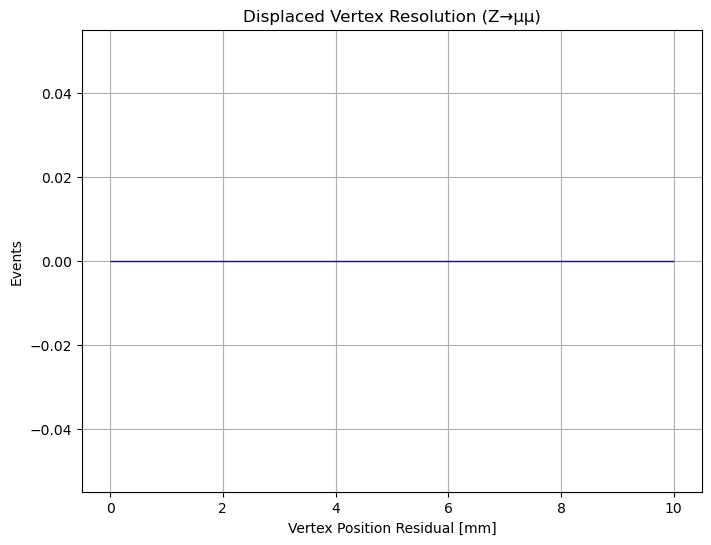

Small residuals for Z→μμ; expect broader for HNLs at 2–10 m.


In [ ]:

# Extract vertex data
mc_pdg = tree["MCParticles.PDG"].array()
mc_vx = tree["MCParticles.vertex.x"].array()
mc_vy = tree["MCParticles.vertex.y"].array()
mc_vz = tree["MCParticles.vertex.z"].array()
reco_vx = tree["VertexBarrelCollection.position.x"].array()
reco_vy = tree["VertexBarrelCollection.position.y"].array()
reco_vz = tree["VertexBarrelCollection.position.z"].array()

# Select muons (PDG = 13, -13; for HNLs, use 9900012)
muon_mask = (abs(mc_pdg) == 13)
mc_vx_muon = ak.flatten(mc_vx[muon_mask])
mc_vy_muon = ak.flatten(mc_vy[muon_mask])
mc_vz_muon = ak.flatten(mc_vz[muon_mask])

# Flatten reconstructed vertices (simplified matching)
reco_vx_flat = ak.flatten(reco_vx)
reco_vy_flat = ak.flatten(reco_vy)
reco_vz_flat = ak.flatten(reco_vz)

# Ensure same length (use minimum length for Z→μμ)
min_len = min(len(mc_vx_muon), len(reco_vx_flat))
mc_vx_muon = mc_vx_muon[:min_len]
mc_vy_muon = mc_vy_muon[:min_len]
mc_vz_muon = mc_vz_muon[:min_len]
reco_vx_flat = reco_vx_flat[:min_len]
reco_vy_flat = reco_vy_flat[:min_len]
reco_vz_flat = reco_vz_flat[:min_len]

# Calculate residuals
delta_x = reco_vx_flat - mc_vx_muon
delta_y = reco_vy_flat - mc_vy_muon
delta_z = reco_vz_flat - mc_vz_muon
vertex_residual = np.sqrt(ak.Array(delta_x**2 + delta_y**2 + delta_z**2))

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(ak.to_numpy(vertex_residual), bins=50, range=(0, 10), histtype='step', color='blue')
plt.xlabel('Vertex Position Residual [mm]')
plt.ylabel('Events')
plt.title('Displaced Vertex Resolution (Z→μμ)')
plt.grid(True)
plt.savefig('vertex_resolution.png')
plt.show()

print("Small residuals for Z→μμ; expect broader for HNLs at 2–10 m.")

In [ ]:
import os, matplotlib.pyplot as plt
OUT_DIR = "/web/omunkombwe/public_html"
os.makedirs(OUT_DIR, exist_ok=True)
nb = "trackImpactPara"
nums = plt.get_fignums()
for i, num in enumerate(nums, 1):
    fig = plt.figure(num)
    fname = f"{nb}_fig{i}.png"
    fig.savefig(fname, dpi=150)
print(f"Saved {len(nums)} figure(s) to {OUT_DIR}")
